In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
train = pd.read_csv(
    "/content/train_FD001.txt",
    sep=r"\s+",
    header=None
)

In [ ]:
test = pd.read_csv(
    "/content/test_FD001.txt",
    sep=r"\s+",
    header=None
)

In [ ]:
rul = pd.read_csv(
    "/content/RUL_FD001.txt",
    header=None
)

In [ ]:
columns = (
    ['unit', 'cycle',
     'op_setting_1', 'op_setting_2', 'op_setting_3']
    + [f'sensor_{i}' for i in range(1, 22)]
)

train.columns = columns
test.columns = columns

In [ ]:
print("Train Shape:", train.shape)
print("Test Shape :", test.shape)
print("RUL Shape  :", rul.shape)

Train Shape: (20631, 26)
Test Shape : (13096, 26)
RUL Shape  : (100, 1)


In [ ]:
train.head()

,unit,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   unit          20631 non-null  int64  
 1   cycle         20631 non-null  int64  
 2   op_setting_1  20631 non-null  float64
 3   op_setting_2  20631 non-null  float64
 4   op_setting_3  20631 non-null  float64
 5   sensor_1      20631 non-null  float64
 6   sensor_2      20631 non-null  float64
 7   sensor_3      20631 non-null  float64
 8   sensor_4      20631 non-null  float64
 9   sensor_5      20631 non-null  float64
 10  sensor_6      20631 non-null  float64
 11  sensor_7      20631 non-null  float64
 12  sensor_8      20631 non-null  float64
 13  sensor_9      20631 non-null  float64
 14  sensor_10     20631 non-null  float64
 15  sensor_11     20631 non-null  float64
 16  sensor_12     20631 non-null  float64
 17  sensor_13     20631 non-null  float64
 18  sensor_14     20631 non-nu

In [ ]:
print("Number of Engines :", train["unit"].nunique())

cycles_per_engine = train.groupby("unit")["cycle"].max()

print("\nCycles per Engine:")
print(cycles_per_engine)

Number of Engines : 100

Cycles per Engine:
unit
1      192
2      287
3      179
4      189
5      269
      ... 
96     336
97     202
98     156
99     185
100    200
Name: cycle, Length: 100, dtype: int64


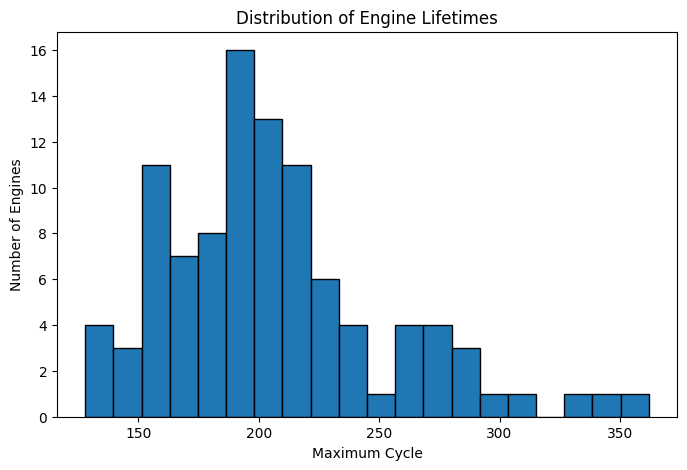

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(cycles_per_engine, bins=20, edgecolor="black")

plt.title("Distribution of Engine Lifetimes")
plt.xlabel("Maximum Cycle")
plt.ylabel("Number of Engines")

plt.show()

### Observation

The engine lifetime distribution exhibits a positively skewed shape, with most engines failing between approximately 150 and 230 operating cycles. However, a small number of engines survive for more than 300 cycles, indicating substantial variability in degradation behavior across the fleet.

This variation confirms that engines do not share a common lifespan and emphasizes the importance of using sensor measurements rather than cycle count alone for Remaining Useful Life (RUL) prediction.

In [ ]:
train[["op_setting_1", "op_setting_2", "op_setting_3"]].describe().T

,count,mean,std,min,25%,50%,75%,max
op_setting_1,20631.0,-0.000009,0.002187,-0.0087,-0.0015,0.0,0.0015,0.0087
op_setting_2,20631.0,0.000002,0.000293,-0.0006,-0.0002,0.0,0.0003,0.0006
op_setting_3,20631.0,100.000000,0.000000,100.0000,100.0000,100.0,100.0000,100.0000


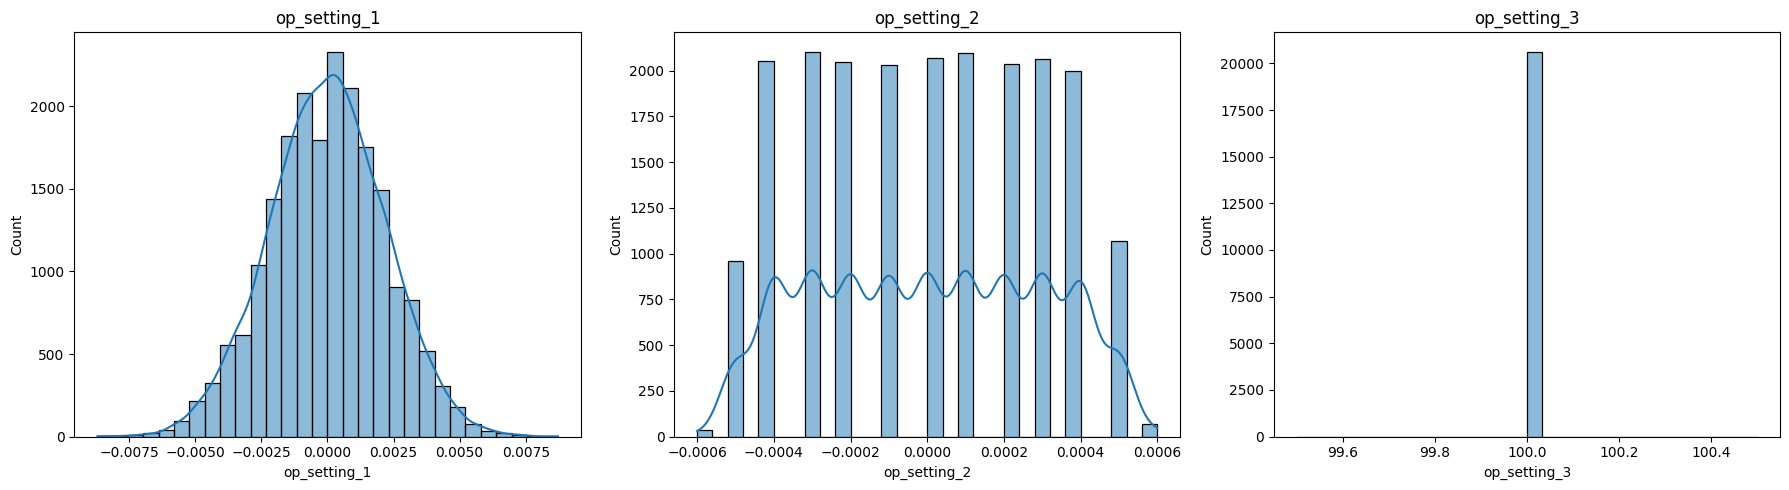

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18,5))

settings = ["op_setting_1", "op_setting_2", "op_setting_3"]

for i, col in enumerate(settings):
    sns.histplot(
        train[col],
        bins=30,
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(col)

plt.tight_layout()
plt.show()

### Observation

- **op_setting_1:** Displays an approximately normal (Gaussian) distribution centered around zero with a symmetric shape. The variable exhibits continuous values and moderate variability, suggesting it may contain useful operational information.

- **op_setting_2:** Shows a discrete, multimodal distribution with values concentrated at several predefined operating levels. Although represented as a numerical feature, it behaves similarly to a categorical or quantized variable.

- **op_setting_3:** Remains completely constant at a value of 100 across all 20,631 observations. The summary statistics confirm zero variance (standard deviation = 0), indicating that this feature carries no discriminative information.

In [ ]:
sensor_cols = [col for col in train.columns if col.startswith("sensor_")]

train[sensor_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
sensor_1,20631.0,518.670000,6.537152e-11,518.6700,518.6700,518.6700,518.6700,518.6700
sensor_2,20631.0,642.680934,5.000533e-01,641.2100,642.3250,642.6400,643.0000,644.5300
sensor_3,20631.0,1590.523119,6.131150e+00,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100
sensor_4,20631.0,1408.933782,9.000605e+00,1382.2500,1402.3600,1408.0400,1414.5550,1441.4900
sensor_5,20631.0,14.620000,3.394700e-12,14.6200,14.6200,14.6200,14.6200,14.6200
sensor_6,20631.0,21.609803,1.388985e-03,21.6000,21.6100,21.6100,21.6100,21.6100
sensor_7,20631.0,553.367711,8.850923e-01,549.8500,552.8100,553.4400,554.0100,556.0600
sensor_8,20631.0,2388.096652,7.098548e-02,2387.9000,2388.0500,2388.0900,2388.1400,2388.5600
sensor_9,20631.0,9065.242941,2.208288e+01,9021.7300,9053.1000,9060.6600,9069.4200,9244.5900
sensor_10,20631.0,1.300000,4.660829e-13,1.3000,1.3000,1.3000,1.3000,1.3000


In [ ]:
variance = train[sensor_cols].var().sort_values()

variance

,0
sensor_19,0.000000e+00
sensor_18,0.000000e+00
sensor_16,2.422479e-28
sensor_10,2.172333e-25
sensor_5,1.152399e-23
sensor_1,4.273435e-21
sensor_6,1.929279e-06
sensor_15,1.406628e-03
sensor_8,5.038938e-03
sensor_13,5.172330e-03


### Observation

The variance analysis reveals a clear separation between constant and informative sensor measurements.

- **Zero-Variance Sensors:** `sensor_1`, `sensor_5`, `sensor_10`, `sensor_16`, `sensor_18`, and `sensor_19` exhibit virtually zero variance, indicating that their values remain constant throughout the entire dataset. Such features cannot contribute to distinguishing different engine health conditions.

- **Low-Variance Sensor:** `sensor_6` shows extremely limited variability compared to the remaining sensors. Although it is not strictly constant, its measurements fluctuate only within a very narrow range.

- **High-Variance Sensors:** `sensor_9`, `sensor_14`, `sensor_4`, and `sensor_3` display the largest variability, suggesting that they capture substantial changes during engine degradation and may provide valuable information for Remaining Useful Life prediction.

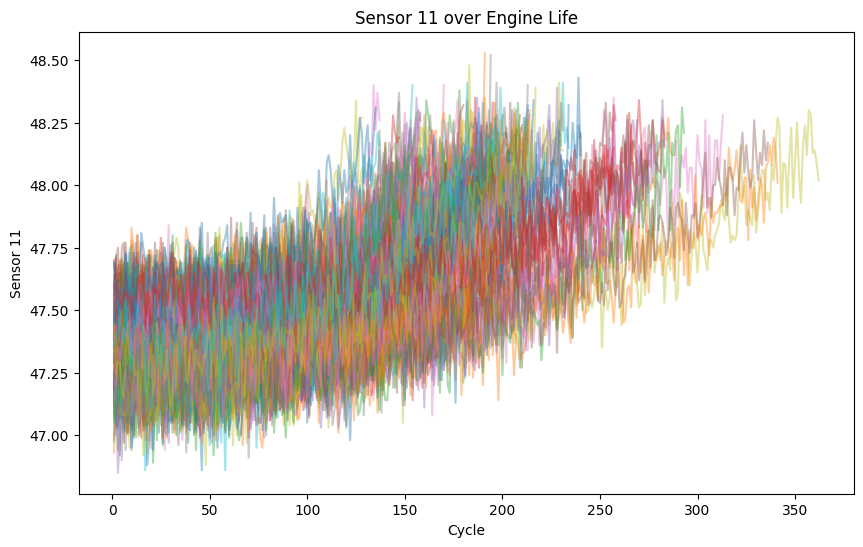

In [ ]:
plt.figure(figsize=(10,6))

for engine in train["unit"].unique():
    engine_data = train[train["unit"] == engine]
    plt.plot(
        engine_data["cycle"],
        engine_data["sensor_11"],
        alpha=0.4
    )

plt.title("Sensor 11 over Engine Life")
plt.xlabel("Cycle")
plt.ylabel("Sensor 11")
plt.show()

### Observation

Sensor 11 exhibits a clear degradation pattern throughout the engine lifetime.

- During the early operating cycles, most engines show relatively stable Sensor 11 readings with only minor fluctuations.
- As the number of cycles increases, Sensor 11 gradually rises, indicating progressive engine degradation.
- The variability between engine trajectories becomes larger in the later stages of operation, suggesting that engines degrade at different rates.
- Although short-term fluctuations are present, the overall increasing trend remains consistent across most engines.

These characteristics indicate that Sensor 11 captures meaningful health-related information and reflects the degradation process before engine failure.

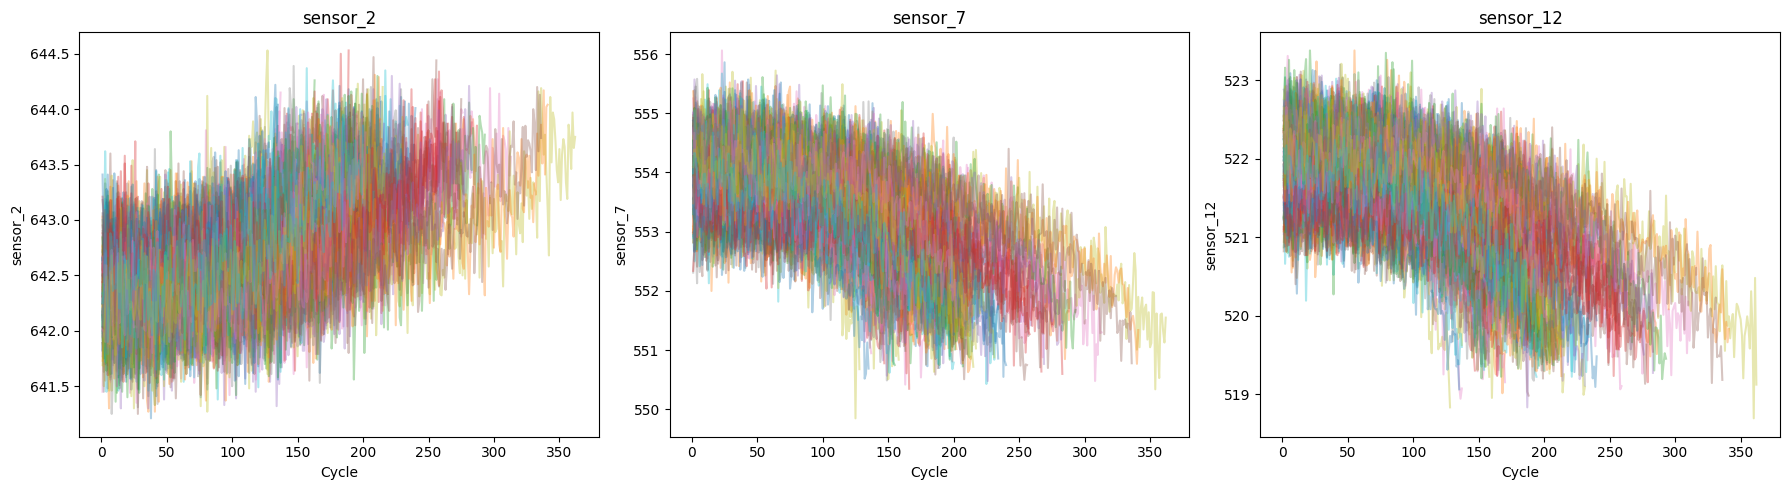

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

selected_sensors = ["sensor_2", "sensor_7", "sensor_12"]

for ax, sensor in zip(axes, selected_sensors):
    for engine in train["unit"].unique():
        engine_data = train[train["unit"] == engine]
        ax.plot(
            engine_data["cycle"],
            engine_data[sensor],
            alpha=0.35
        )

    ax.set_title(sensor)
    ax.set_xlabel("Cycle")
    ax.set_ylabel(sensor)

plt.tight_layout()
plt.show()

### Observation

The time-series analysis of **sensor_2**, **sensor_7**, and **sensor_12** reveals consistent degradation patterns throughout the engine lifetime.

- **sensor_2** exhibits a gradual increasing trend as the engine approaches failure.
- **sensor_7** and **sensor_12** show the opposite behavior, with values progressively decreasing over time.
- Although individual engines degrade at different rates, the overall direction of change remains remarkably consistent across the fleet.
- The spread between engine trajectories increases during the later operating cycles, indicating variability in degradation rates among different engines.
- Short-term fluctuations and measurement noise are present; however, they do not obscure the overall degradation trends.

These sensors clearly reflect the health evolution of the engines and demonstrate strong temporal relationships with the degradation process.

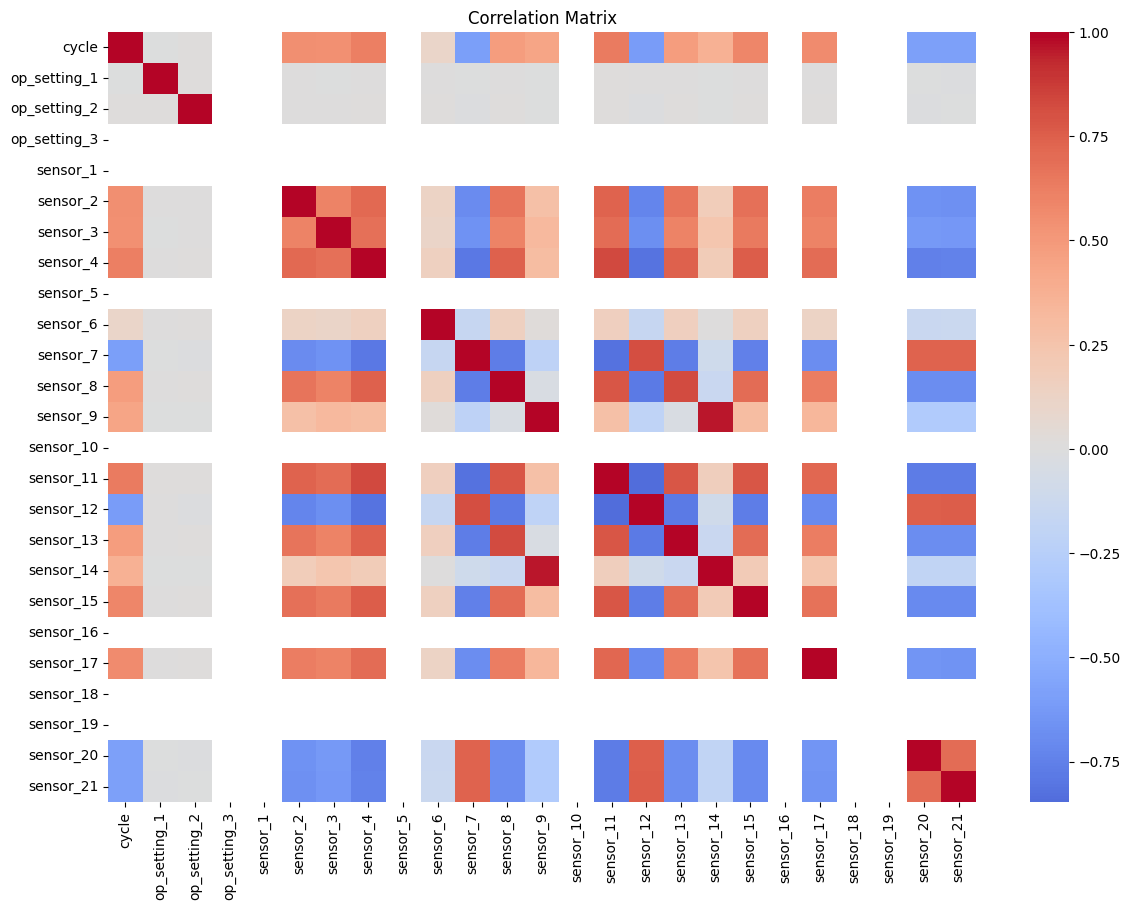

In [ ]:
plt.figure(figsize=(14,10))

corr = train.drop(columns=["unit"]).corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.show()

In [ ]:
corr_matrix = train.drop(columns=["unit"]).corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr = []

for col in upper.columns:
    for row in upper.index:
        if upper.loc[row, col] > 0.95:
            high_corr.append((row, col, upper.loc[row, col]))

high_corr

[('sensor_9', 'sensor_14', np.float64(0.9631566003059776))]

In [ ]:
# Calculate Remaining Useful Life for each engine
train["RUL"] = train.groupby("unit")["cycle"].transform("max") - train["cycle"]

# Apply Piecewise RUL (Cap at 125 cycles)
train["RUL"] = train["RUL"].clip(upper=125)

In [ ]:
train[["unit", "cycle", "RUL"]].head(15)

,unit,cycle,RUL
0,1,1,125
1,1,2,125
2,1,3,125
3,1,4,125
4,1,5,125
5,1,6,125
6,1,7,125
7,1,8,125
8,1,9,125
9,1,10,125


In [ ]:
train.groupby("unit")["RUL"].agg(["max", "min"]).head()

,max,min
unit,,
1,125,0
2,125,0
3,125,0
4,125,0
5,125,0


In [ ]:
drop_cols = [
    "op_setting_3",
    "sensor_1",
    "sensor_5",
    "sensor_10",
    "sensor_16",
    "sensor_18",
    "sensor_19"
]

train = train.drop(columns=drop_cols)
test = test.drop(columns=drop_cols)

print("Train Shape:", train.shape)
print("Test Shape :", test.shape)

Train Shape: (20631, 20)
Test Shape : (13096, 19)


In [ ]:
from sklearn.model_selection import train_test_split

# Get unique engine IDs
engine_ids = train["unit"].unique()

# Split engines into training and validation sets
train_engines, val_engines = train_test_split(
    engine_ids,
    test_size=0.2,
    random_state=42
)

# Create train and validation datasets
train_df = train[train["unit"].isin(train_engines)].copy()
val_df = train[train["unit"].isin(val_engines)].copy()

print("Training Engines :", len(train_engines))
print("Validation Engines :", len(val_engines))

print("\nTraining Shape :", train_df.shape)
print("Validation Shape :", val_df.shape)

print("\nCommon Engines :", set(train_engines) & set(val_engines))

Training Engines : 80
Validation Engines : 20

Training Shape : (16561, 20)
Validation Shape : (4070, 20)

Common Engines : set()


In [ ]:
# Features
X_train = train_df.drop(columns=["unit", "cycle", "RUL"])
X_val = val_df.drop(columns=["unit", "cycle", "RUL"])

X_test = test.drop(columns=["unit", "cycle"])

# Targets
y_train = train_df["RUL"]
y_val = val_df["RUL"]

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(16561, 17)
(4070, 17)
(13096, 17)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [ ]:
import xgboost as xgb



In [ ]:
print(xgb.__version__)

3.2.0


In [ ]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
import numpy as np

y_pred = xgb_model.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, y_pred))
mae = mean_absolute_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)

print("Validation Results")
print(f"RMSE : {rmse:.3f}")
print(f"MAE  : {mae:.3f}")
print(f"R²   : {r2:.4f}")

Validation Results
RMSE : 16.950
MAE  : 12.157
R²   : 0.8349


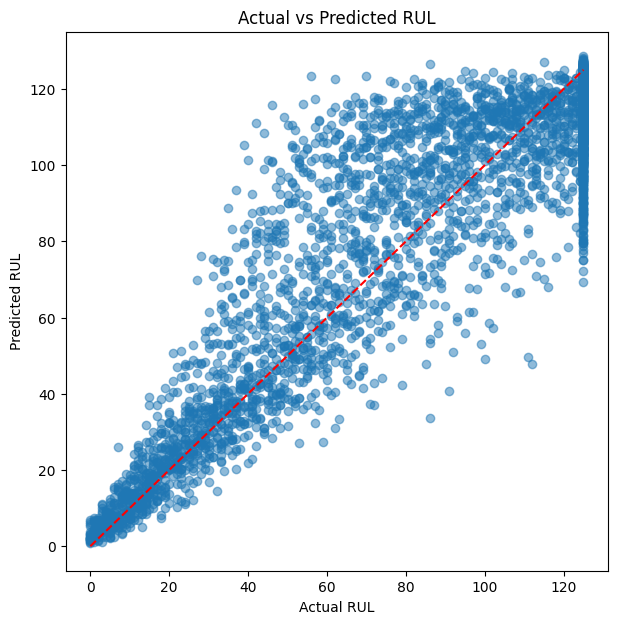

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))

plt.scatter(y_val, y_pred, alpha=0.5)

plt.plot(
    [0,125],
    [0,125],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Actual vs Predicted RUL")

plt.show()

In [ ]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X_train.columns if hasattr(X_train, "columns") else train_df.drop(columns=["unit","cycle","RUL"]).columns,
    "Importance": xgb_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
9,sensor_11,0.451524
4,sensor_4,0.187895
8,sensor_9,0.090175
10,sensor_12,0.053808
12,sensor_14,0.031337
13,sensor_15,0.029409
6,sensor_7,0.024820
11,sensor_13,0.020983
15,sensor_20,0.019122
14,sensor_17,0.018517


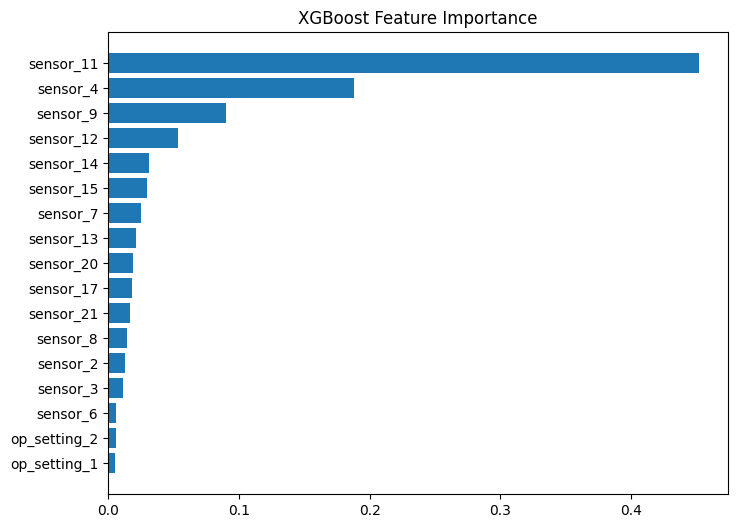

In [ ]:
plt.figure(figsize=(8,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("XGBoost Feature Importance")

plt.show()

In [ ]:
test_last = test.groupby("unit").last().reset_index()

print(test_last.shape)
test_last.head()

(100, 19)


,unit,cycle,op_setting_1,op_setting_2,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21
0,1,31,-0.0006,0.0004,642.58,1581.22,1398.91,21.61,554.42,2388.08,9056.40,47.23,521.79,2388.06,8130.11,8.4024,393,38.81,23.3552
1,2,49,0.0018,-0.0001,642.55,1586.59,1410.83,21.61,553.52,2388.10,9044.77,47.67,521.74,2388.09,8126.90,8.4505,391,38.81,23.2618
2,3,126,-0.0016,0.0004,642.88,1589.75,1418.89,21.61,552.59,2388.16,9049.26,47.88,520.83,2388.14,8131.46,8.4119,395,38.93,23.2740
3,4,106,0.0012,0.0004,642.78,1594.53,1406.88,21.61,552.64,2388.13,9051.30,47.65,521.88,2388.11,8133.64,8.4634,395,38.58,23.2581
4,5,98,-0.0013,-0.0004,642.27,1589.94,1419.36,21.61,553.29,2388.10,9053.99,47.46,521.00,2388.15,8125.74,8.4362,394,38.75,23.4117


In [ ]:
X_test_final = test_last.drop(columns=["unit","cycle"])

X_test_final = scaler.transform(X_test_final)

In [ ]:
test_pred = xgb_model.predict(X_test_final)

In [ ]:
y_test = rul.iloc[:,0]

In [ ]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, test_pred))
mae = mean_absolute_error(y_test, test_pred)
r2 = r2_score(y_test, test_pred)

print(f"RMSE : {rmse:.3f}")
print(f"MAE  : {mae:.3f}")
print(f"R²   : {r2:.4f}")

RMSE : 17.743
MAE  : 13.085
R²   : 0.8177


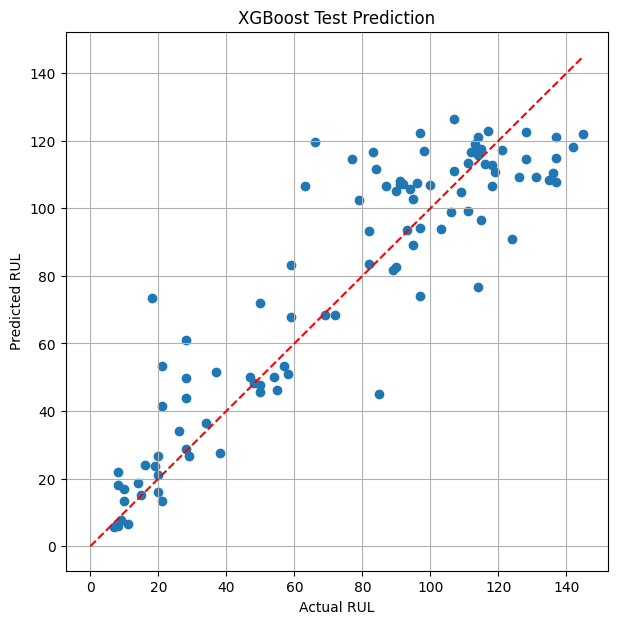

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))

plt.scatter(y_test, test_pred)

plt.plot(
    [0,max(y_test)],
    [0,max(y_test)],
    "r--"
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("XGBoost Test Prediction")

plt.grid(True)

plt.show()

The XGBoost model achieved strong predictive performance on the CMAPSS FD001 dataset, obtaining an RMSE of 17.74, an MAE of 13.09, and an R² score of 0.818. The model accurately captured the degradation behavior during the late stages of engine life, where predictive maintenance decisions are most critical. Slight underestimation was observed for engines with very high Remaining Useful Life values due to the application of Piecewise RUL capping at 125 cycles, which is a common preprocessing strategy in the literature.

In [ ]:
import joblib

joblib.dump(xgb_model, "xgboost_rul_model.pkl")

print("XGBoost model saved successfully")

XGBoost model saved successfully


In [ ]:
joblib.dump(scaler, "standard_scaler.pkl")

print("Scaler saved successfully!")

Scaler saved successfully!


In [ ]:
feature_names = train_df.drop(
    columns=["unit", "cycle", "RUL"]
).columns.tolist()

joblib.dump(feature_names, "feature_names.pkl")

print("Feature names saved successfully!")

Feature names saved successfully!


In [ ]:
import os

print(os.listdir())

['.config', 'train_FD001.txt', 'RUL_FD001.txt', 'test_FD001.txt', 'xgboost_rul_model.pkl', 'feature_names.pkl', 'standard_scaler.pkl', 'sample_data']


In [ ]:
from google.colab import files

files.download("xgboost_rul_model.pkl")
files.download("standard_scaler.pkl")
files.download("feature_names.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install shap

In [ ]:
import shap
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
feature_names = train_df.drop(
    columns=["unit", "cycle", "RUL"]
).columns

In [ ]:
X_train_df = pd.DataFrame(
    X_train,
    columns=feature_names
)

X_val_df = pd.DataFrame(
    X_val,
    columns=feature_names
)

In [ ]:
explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_val_df)

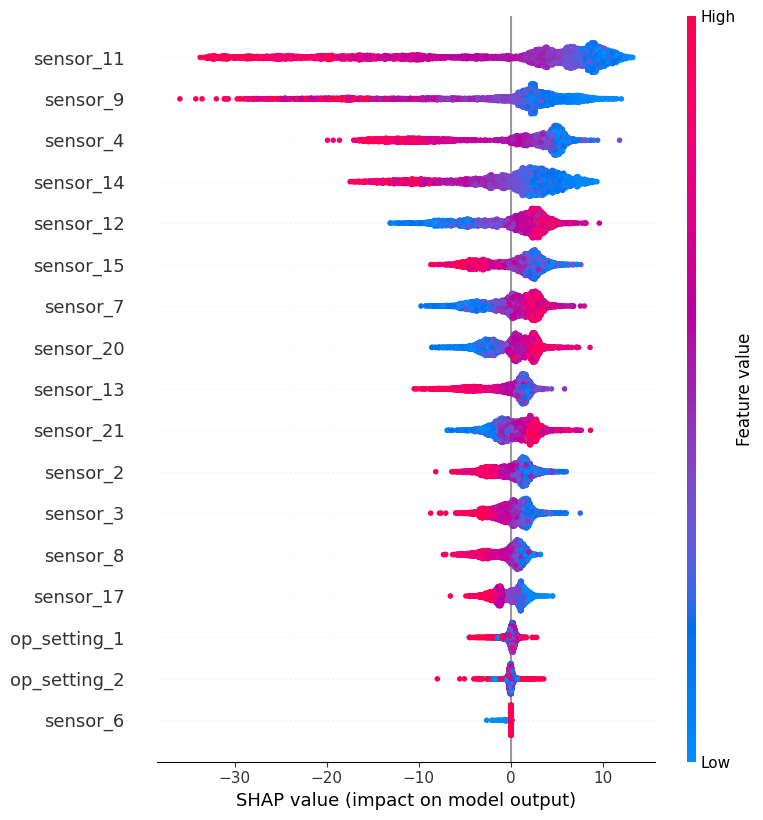

In [ ]:
shap.summary_plot(
    shap_values,
    X_val_df
)

Observation

The SHAP analysis provides a transparent explanation of how the XGBoost model estimates the Remaining Useful Life. Increasing values in sensors such as sensor_11, sensor_9, and sensor_4, together with decreasing values in sensor_12, sensor_7, sensor_20, and sensor_21, consistently push the prediction toward lower RUL values. These patterns closely match the degradation behavior observed during the time-series analysis, demonstrating that the model has successfully learned meaningful degradation signatures rather than arbitrary statistical relationships. Additionally, operational settings and near-constant sensors exhibit negligible SHAP values, confirming their limited contribution to the prediction process.

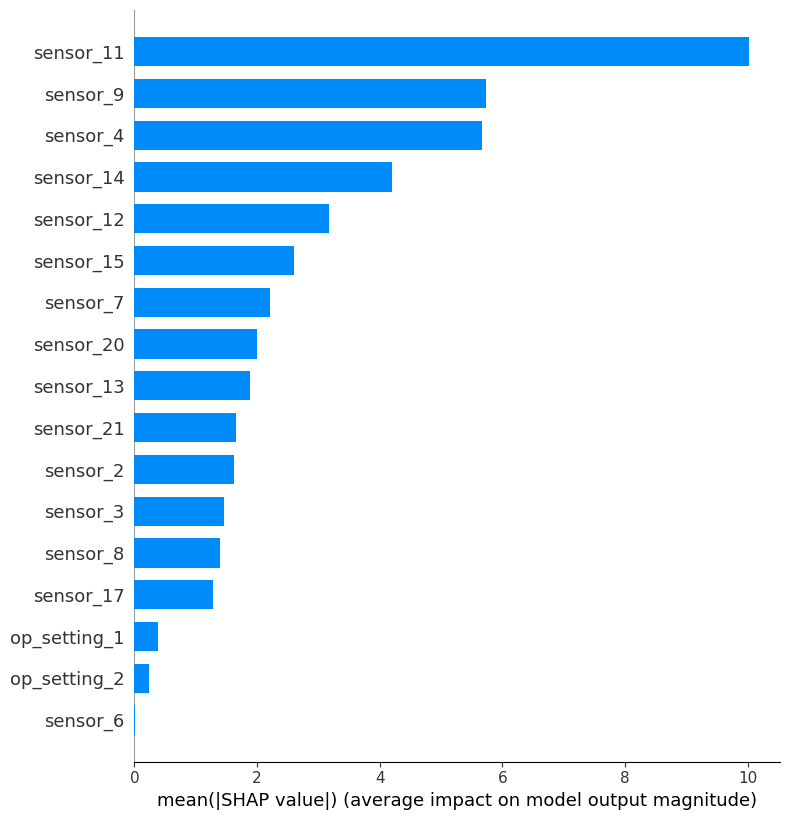

In [ ]:
shap.summary_plot(
    shap_values,
    X_val_df,
    plot_type="bar"
)

Observation

The global SHAP feature importance confirms that the XGBoost model relies primarily on a small group of highly informative degradation sensors, with sensor_11, sensor_9, sensor_4, sensor_14, and sensor_12 providing the largest overall contributions to the Remaining Useful Life predictions. Unlike the built-in XGBoost importance, SHAP distributes importance more fairly among correlated features, revealing that both increasing and decreasing sensor groups actively contribute to the prediction process. Furthermore, the operational settings and near-constant sensors exhibit negligible SHAP values, confirming their limited influence on model behavior.

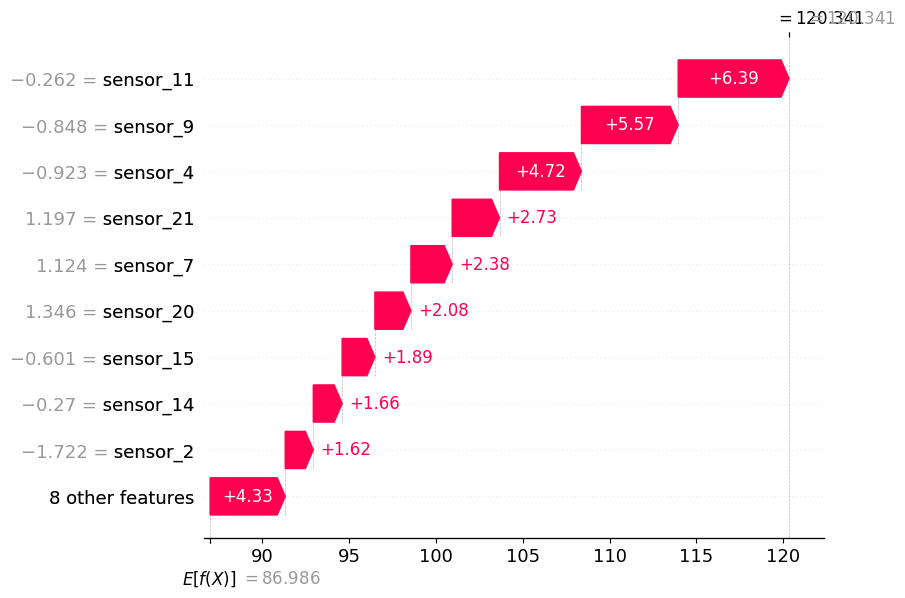

In [ ]:
sample = 0

explanation = shap.Explanation(
    values=shap_values[sample],
    base_values=explainer.expected_value,
    data=X_val_df.iloc[sample],
    feature_names=feature_names
)

shap.plots.waterfall(explanation)

Observation

The SHAP waterfall plot provides a transparent explanation of an individual prediction by showing how each feature contributes to the final Remaining Useful Life estimate. Starting from the dataset's expected prediction, multiple sensor readings collectively increase the predicted RUL to approximately 120.3 cycles. The largest positive contributions come from sensor_11, sensor_9, and sensor_4, while several additional sensors provide smaller supporting contributions. The observed sensor pattern closely matches the degradation signatures associated with engines having high remaining useful life, demonstrating that the model's prediction is based on meaningful operational behavior rather than arbitrary statistical relationships.